Bu kısımda, modellerimizin başarı skorlarını arttırmak için yeni özellik eklemeleri yapacak ve daha yüksek skor alabilecek miyiz diye görmek için başka sınıflandırma modellerini deneyeceğiz.

In [6]:
import pandas as pd
import numpy as np
import csv
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [7]:
try:
    df = pd.read_csv("final_data2.csv",
                    sep=',',
                    on_bad_lines='skip',
                    engine='c',
                    quoting=csv.QUOTE_MINIMAL)
    print(f"Veri seti yüklendi. Satır sayısı: {len(df)}")
except:
    df = pd.read_csv("final_data2.csv", on_bad_lines='skip', engine='python')

Veri seti yüklendi. Satır sayısı: 20405


In [9]:
def extract_features_v2(text):
    text = str(text)
    words = text.split()
    num_words = len(words) if len(words) > 0 else 1
    text_len = len(text) if len(text) > 0 else 1

    # Mevcutlar
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    lexical_div = len(set(words)) / num_words
    caps_ratio = sum(1 for c in text if c.isupper()) / text_len
    excl_count = text.count('!')

    avg_word_len = sum(len(word) for word in words) / num_words # haberin ortalama kelime uzunluğu
    q_mark_count = text.count('?') # haberde kullanılan soru işareti sayısı
    digit_ratio = sum(c.isdigit() for c in text) / text_len # haberin sayısal karakter oranı

    return pd.Series([num_words, sentiment, subjectivity, lexical_div, caps_ratio, excl_count,
                      avg_word_len, q_mark_count, digit_ratio]) # seri olarak returnle

Eklediğimiz 3 yeni özellik şu şekilde:

avg_word_len : Haberlerin ortalama kelime uzunluğu

q_mark_count : Haberde kullanılan soru işareti sayısı

digit_ratio : Haberdeki sayısal karakterlerin oranı

In [10]:
new_feature_names = ['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count',
                     'avg_word_len', 'q_mark_count', 'digit_ratio']

df[new_feature_names] = df['full_text'].apply(extract_features_v2)

In [11]:
df.head()

,title,label,clean_title,full_text,word_count,sentiment,subjectivity,lexical_div,caps_ratio,excl_count,avg_word_len,q_mark_count,digit_ratio
0,"The 2018 Holiday Gift For Your Partner, Based ...",0,2018 holiday gift partner based zodiac sign,"Since we're in the midst of Hanukkah, and Chri...",859.0,0.193464,0.513658,0.544820,0.022732,1.0,4.911525,3.0,0.012150
1,Gen-Z Takes The MTV Movie & TV Awards Red Carp...,0,genz takes mtv movie awards red carpet storm,Entertainment\n\nHow Michaela Coel Pulled Off ...,37.0,0.000000,0.000000,1.000000,0.086207,0.0,5.243243,0.0,0.017241
2,Look What You Made Me Do,0,look made,"2017 single by Taylor Swift\n\n""Look What You ...",5396.0,0.095222,0.403197,0.372683,0.036833,4.0,5.067272,5.0,0.028112
3,Selena Gomez Wore 6 Outfits in 1 Day — But She...,0,selena gomez wore outfits day loved date night...,Selena Gomez and the Weeknd stepped out for da...,320.0,0.125938,0.390296,0.621875,0.049025,0.0,4.843750,0.0,0.003690
4,Eric Roberts,0,eric roberts,(1956-)\n\nSynopsis\n\nActor Eric Roberts was ...,747.0,0.018087,0.346635,0.519411,0.049755,1.0,4.945114,0.0,0.015172


Bu şekilde yeni özelliklerimizi dataframe imize ekledik. Şimdi yeniden sınıflandırma ve tahminlerimizi yapacağız

Ancak kontrol etmek adına yeni özellikler eklediğimizde, optimizasyon için bulduğumuz değerler değişmiş mi diye bir kontrol edelim.

In [ ]:
k_values = range(1, 21) # k nin değer aralığı
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())  # skorların ortalamasını alarak en iyisini buluruz





In [ ]:
best_k = k_values[np.argmax(k_scores)]
print(f"En iyi K değeri: {best_k} (Başarı: %{max(k_scores)*100:.2f})")

En iyi K değeri: 12 (Başarı: %77.78)


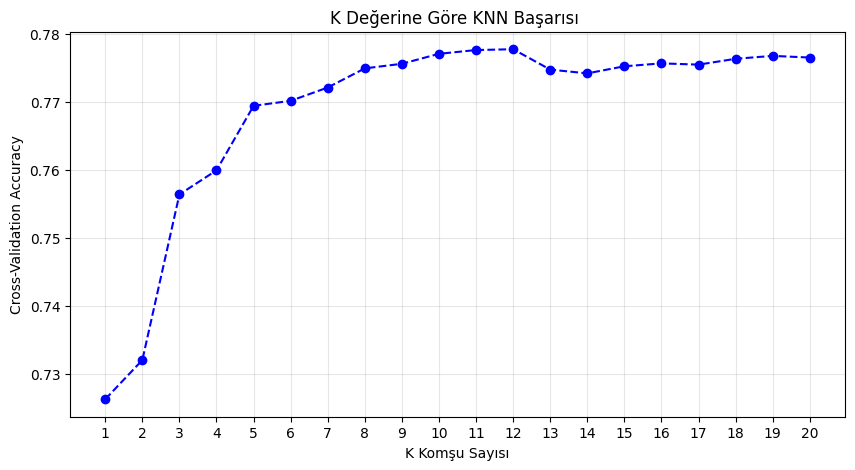

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, k_scores, marker='o', linestyle='--', color='blue')
plt.title('K Değerine Göre KNN Başarısı ')
plt.xlabel('K Komşu Sayısı')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

Önceki en iyi K değeri 17 iken şuan 12 olmuş durumda

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20,None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"En İyi RF Parametreleri: {grid_search.best_params_}")

En İyi RF Parametreleri: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


RF parametreleri aynı neredeyse, sadece max depth none iken şuan 20 olmuş.

In [44]:
# Logistic Regression Optimizasyonu
param_grid_lr = {'C': [0.1, 1, 10, 100], 'penalty': ['l2']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
print(f"LR için en iyi C değeri: {grid_lr.best_params_['C']}")

LR için en iyi C değeri: 100


LR için en iyi C değeri de hala 100

In [45]:
df = df.dropna(subset=new_feature_names + ['label'])
X = df[new_feature_names]
y = df['label'].astype(int)

In [46]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

In [67]:
best_models = {
    "LR (C=100)": LogisticRegression(C=100, max_iter=1000),
    "KNN (K=17)": KNeighborsClassifier(n_neighbors=12),
    "Random Forest (Best)": RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=20, random_state=42)
}

print("\n--- 10-Fold Cross Validation Sonuçları (Yeni Özelliklerle) ---")
for name, model in best_models.items():
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{name:25}: Ortalama Accuracy = %{scores.mean()*100:.2f}")


--- 10-Fold Cross Validation Sonuçları (Yeni Özelliklerle) ---
LR (C=100)               : Ortalama Accuracy = %77.82
KNN (K=17)               : Ortalama Accuracy = %77.82
Random Forest (Best)     : Ortalama Accuracy = %82.61


Özellikleri eklemeden önce yaptığımız cross validation sonuçları bundan çok daha düşüktü.Önceki sonuçlar:

Logistic Regression : Ortalama Başarı (Accuracy) = %72.51 ----> 77.82

K-Nearest Neighbors : Ortalama Başarı (Accuracy) = %73.78 ----> 77.82

Random Forest       : Ortalama Başarı (Accuracy) = %79.05 ----> 82.61

Bu şekildeydi. Şuan aldığımız sonuçlar bunların üzerinde olduğunu ve eklediğimiz özelliklerin faydalı olduğunu gösteriyor.

Logistic regression ve KNN için yaklaiık % 5 lik artış söz konusu iken, Random forest modelinde % 3,5 'a yakın bir artış var ki performansımızı arttırmak için çok iyi bir sonuç.

In [68]:
rf_final = best_models["Random Forest (Best)"]
rf_final.fit(X_train, y_train)
y_pred = rf_final.predict(X_test)
y_prob = rf_final.predict_proba(X_test)[:, 1]

print("\n--- YENİLENMİŞ FINAL SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))


--- YENİLENMİŞ FINAL SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      2091
           1       0.82      0.80      0.81      1990

    accuracy                           0.82      4081
   macro avg       0.82      0.82      0.82      4081
weighted avg       0.82      0.82      0.82      4081



Skorlarımız daha iyi hale geldiler.

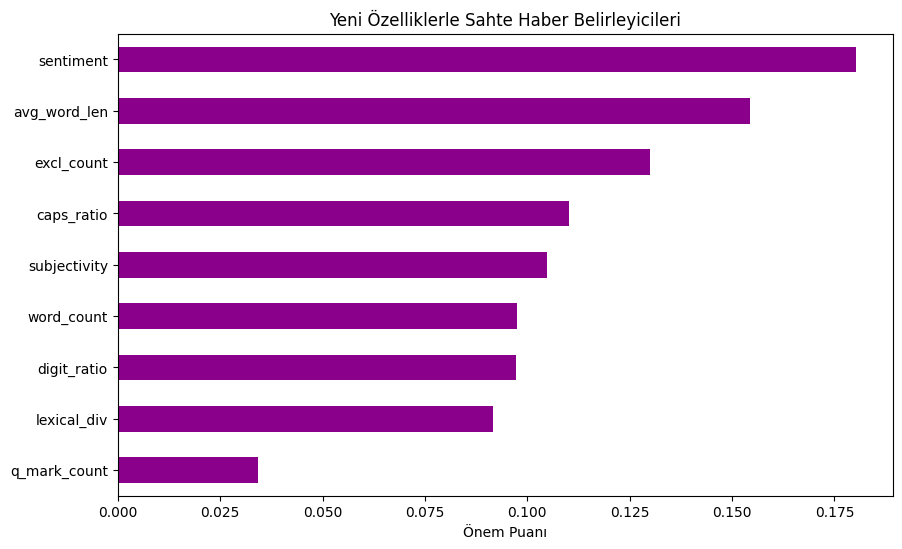

In [69]:
plt.figure(figsize=(10,6))
feat_importances = pd.Series(rf_final.feature_importances_, index=new_feature_names)
feat_importances.sort_values().plot(kind='barh', color='darkmagenta')
plt.title('Yeni Özelliklerle Sahte Haber Belirleyicileri')
plt.xlabel('Önem Puanı')
plt.show()

Yeni eklediğimiz ortalama kelime uzunluğu sahte haberlerin belirlenmesinde büyük rol oynadı.Sentiment hala birinci sırada ancak exclamation count yani ünlem sayısı 3.sıraya gerilemiş durumda.Yeni eklediğimiz Soru işareti sayısı ise en az belirleyen olmuş ancak yine de işe yarar bir özellik.

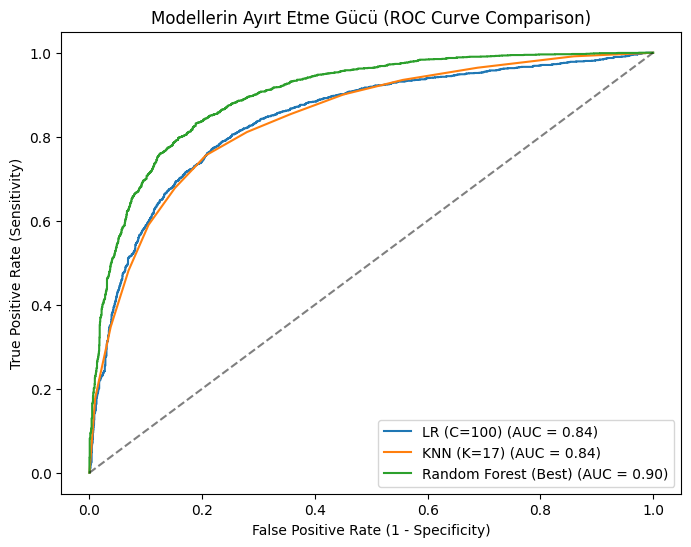

In [70]:
plt.figure(figsize=(8,6))
for name, model in best_models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Modellerin Ayırt Etme Gücü (ROC Curve Comparison)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend()
plt.show()

Eski AUC değerleri şöyleydi:

Logistic Regression: 0.81 --> 0.84

KNN: 0.81 --> 0.84

Random Forest: 0.87 --> 0.90

Her birinde 0.03 lük artış var, eğrinin altında kalan alan bizim modelimizin ayırt etme gücünü temsil ediyor,random forest olduğunu zaten biliyorduk ve bir kez daha görmüş olduk.Random forest için 0.90 AUC değeri oldukça iyi kabul ediliyor.Sol üst köşeye çok yakın olmasa da yeterli seviyede gözüküyor


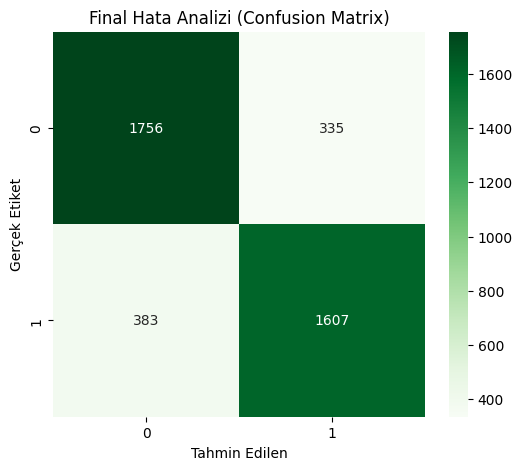


--- FINAL SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      2091
           1       0.83      0.81      0.82      1990

    accuracy                           0.82      4081
   macro avg       0.82      0.82      0.82      4081
weighted avg       0.82      0.82      0.82      4081



In [71]:
# Modeli test setinde çalıştıralım
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Final Hata Analizi (Confusion Matrix)')
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen')
plt.show()

print("\n--- FINAL SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))

ESKİ DEĞERLER ---> YENİ DEĞERLER

TRUE POSİTİVE: 1660 ---> 1756

FALSE NEGATIVE: 417 ---> 383

TRUE NEGATIVE: 1573 ---> 1607

FALSE POSITIVE: 431 ---> 335

Bu değerlere baktığımızda:

Gerçek haberi doğru tahmin sayımız 96 artmış

Yalan haberi doğru tahmin sayımız 37 artmış

Gerçek haberi yanlış tahmin etme sayımız 34 azalmış

Yalan haberi yanlış tahmin etme sayımız 96 azalmış


In [55]:
features = ['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count','avg_word_len','q_mark_count', 'digit_ratio']

Denediğimiz Modeller dışında lineer olmayan SVM, Decision Tree Karar Ağacı ve AdaBoost modellerinde deneyip skorlarımıza bakacağız.

In [59]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

In [74]:
best_svm = SVC(probability=True, kernel='rbf', random_state=42)
best_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
best_ada = AdaBoostClassifier(n_estimators=100, random_state=42)
best_rf = RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=20, random_state=42)

Eski modellerimizle birleştiriyoruz.

In [75]:
final_models = {
    "Optimized LR": best_lr,
    "Optimized KNN (K=17)": best_knn,
    "Optimized Random Forest": best_rf,
    "Support Vector Machine": best_svm,
    "Decision Tree (Single)": best_dt,
    "AdaBoost": best_ada
}

In [76]:
print("\n--- TÜM MODELLERİN KARŞILAŞTIRMALI CV SONUÇLARI ---")
for name, model in final_models.items():
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{name:25}: Ortalama Accuracy = %{scores.mean()*100:.2f}")


--- TÜM MODELLERİN KARŞILAŞTIRMALI CV SONUÇLARI ---
Optimized LR             : Ortalama Accuracy = %77.82
Optimized KNN (K=17)     : Ortalama Accuracy = %77.82
Optimized Random Forest  : Ortalama Accuracy = %82.61
Support Vector Machine   : Ortalama Accuracy = %78.58
Decision Tree (Single)   : Ortalama Accuracy = %78.36
AdaBoost                 : Ortalama Accuracy = %78.50


/tmp/ipython-input-3569850538.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies, y=model_names, palette='magma')


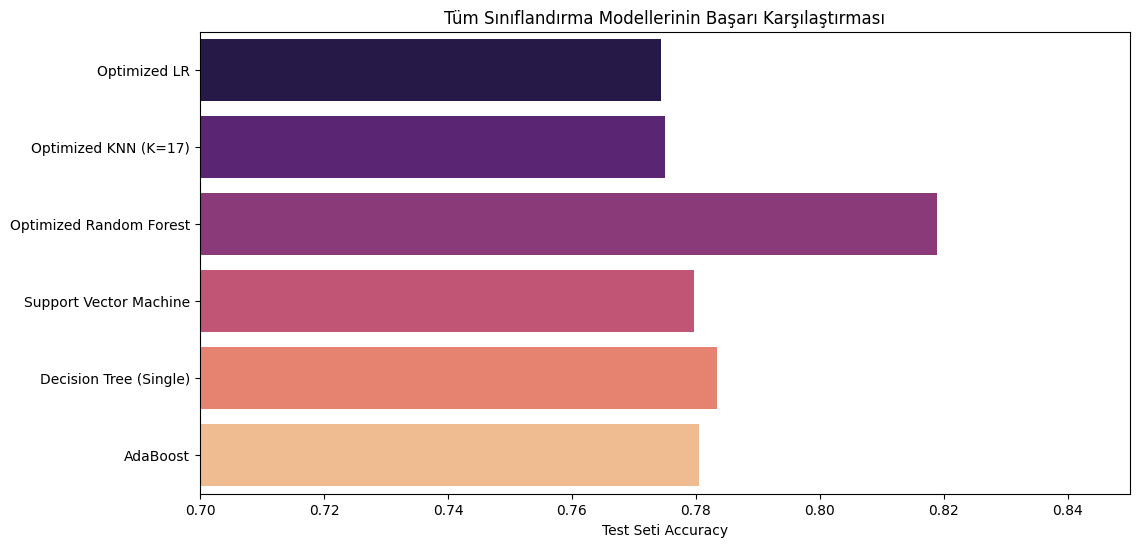

In [77]:
# Tüm modellerin Accuracy skorlarını görselleştirelim
model_names = list(final_models.keys())
accuracies = []

for name, model in final_models.items():
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(12, 6))
sns.barplot(x=accuracies, y=model_names, palette='magma')
plt.xlim(0.70, 0.85)
plt.title('Tüm Sınıflandırma Modellerinin Başarı Karşılaştırması')
plt.xlabel('Test Seti Accuracy')
plt.show()

Yine Random Forest en iyi durumda

Bir de ANN,GBC, VE NB Modellerini Deneyelim

In [78]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

In [66]:
# 1. Yeni modelleri tanımlıyoruz
best_mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42) # MLP
best_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42) # Gradient Boosting
best_nb = GaussianNB() # Naive Bayes (Olasılıksal Sınıflandırma)

# yeni modelleri ekliyoruz
more_models = {
    "Neural Network (ANN)": best_mlp,
    "Gradient Boosting": best_gb,
    "Naive Bayes": best_nb
}

print("\n--- EK MODELLERİN CV SONUÇLARI ---")
for name, model in more_models.items():
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{name:25}: Ortalama Accuracy = %{scores.mean()*100:.2f}")

final_models.update(more_models)


--- EK MODELLERİN CV SONUÇLARI ---
Neural Network (ANN)     : Ortalama Accuracy = %82.49
Gradient Boosting        : Ortalama Accuracy = %81.67
Naive Bayes              : Ortalama Accuracy = %62.05


ANN ve Gradient Boosting Random Forest'a çok yakın ama yine de random forest şuan daha iyi durumda, naive bayes ise çok düşük çıkmış. Bunun sebebi...

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# 1. Parametre Setini Belirleyelim
# learning_rate: Her ağacın hatayı düzeltme hızı
# n_estimators: Toplam ağaç sayısı
# max_depth: Ağaçların derinliği
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

print("Gradient Boosting için en iyi parametreler aranıyor...")
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                        param_grid_gb, cv=5, n_jobs=-1)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print(f"En İyi GBC Parametreleri: {grid_gb.best_params_}")
y_pred_gb = best_gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Optimize Edilmiş Gradient Boosting Accuracy: %{acc_gb*100:.2f}")

Gradient Boosting için en iyi parametreler aranıyor...
En İyi GBC Parametreleri: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Optimize Edilmiş Gradient Boosting Accuracy: %82.43


/tmp/ipython-input-1020390259.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


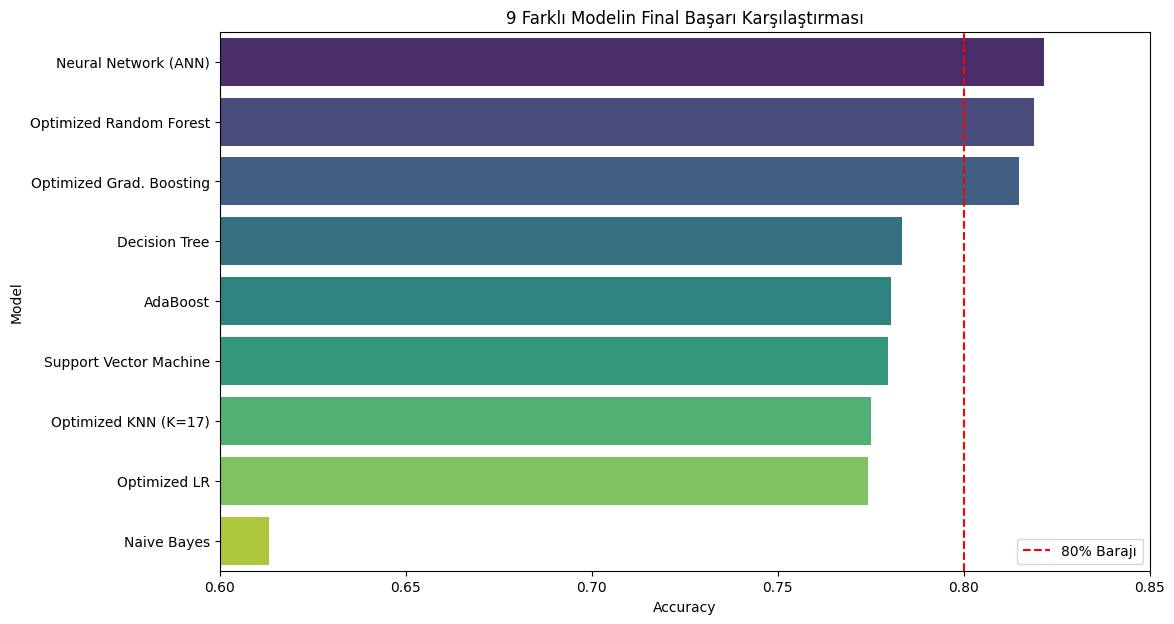

                      Model  Accuracy
4      Neural Network (ANN)  0.821612
2   Optimized Random Forest  0.818917
5  Optimized Grad. Boosting  0.814996
7             Decision Tree  0.783386
6                  AdaBoost  0.780446
3    Support Vector Machine  0.779711
1      Optimized KNN (K=17)  0.775055
0              Optimized LR  0.774320
8               Naive Bayes  0.613330


In [80]:
# Tüm modellerin optimize edilmiş hallerini listeye alalım
final_comparison = {
    "Optimized LR": best_lr,
    "Optimized KNN (K=17)": best_knn,
    "Optimized Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=20, random_state=42),
    "Support Vector Machine": best_svm,
    "Neural Network (ANN)": best_mlp,
    "Optimized Grad. Boosting": best_gb,
    "AdaBoost": best_ada,
    "Decision Tree": best_dt,
    "Naive Bayes": best_nb
}

# Sonuçları hesapla
results_list = []
for name, model in final_comparison.items():
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    results_list.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.axvline(x=0.80, color='red', linestyle='--', label='80% Barajı')
plt.xlim(0.60, 0.85)
plt.title('9 Farklı Modelin Final Başarı Karşılaştırması')
plt.legend()
plt.show()

print(results_df)

10 Fold Cross validation un aksine, şuanki test setimize göre accuracy eğerleri değişti, random forest 1. sırayı Neural Network e bıraktı ve 2. sıraya düştü, gradient boosting de 3. sırada.Ardından gelen değerler 78 77 civarında gidiyor, naive bayes hariç o baya düşük gelmiş.

Şimdi Confusion Matrix'i bir de Neural Network ANN modeliyle deneyelim

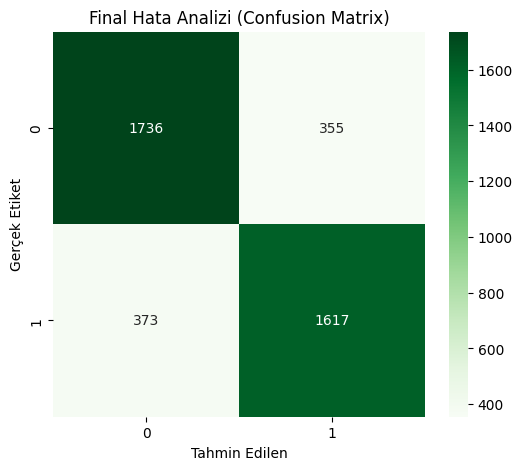


--- FINAL SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      2091
           1       0.82      0.81      0.82      1990

    accuracy                           0.82      4081
   macro avg       0.82      0.82      0.82      4081
weighted avg       0.82      0.82      0.82      4081



In [97]:
# Modeli test setinde çalıştıralım
best_mlp.fit(X_train, y_train)
y_pred = best_mlp.predict(X_test)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Final Hata Analizi (Confusion Matrix)')
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen')
plt.show()

print("\n--- FINAL SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))

Bu değerler aşağı yukarı random forest'ın 10 fold değerleriyle aynı,doğru tahminler ondan çok çok az daha düşükler ve yanlışlar da çok az fazlalar ama bu model yeteri kadar başarılı sayılabilir.

Overfitting-Underfitting Kontrolü

In [82]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print(f"Training Accuracy: %{train_acc*100:.2f}")
print(f"Test Accuracy: %{test_acc*100:.2f}")
print(f"Gap: %{(train_acc - test_acc)*100:.2f}")

Training Accuracy: %98.81
Test Accuracy: %81.89
Gap: %16.91


Train ve Test accuracy arasında çok büyük bir fark varmış. Bu büyük ihtimal modelin ezberlediğine yani overfitting yaptığına işaret,bunu düzeltmemiz gerekiyor.

Düzeltme için modelin derinliğini azaltmamız gerekiyor,çok derinlik verdiğimiz için her detayı ezberliyor.Daha generalization yapabilen bir modele ihtiyacımız var.

In [84]:
best_rf = RandomForestClassifier(
    n_estimators=200,          # ağaç sayısını arttırıp varyansı düşürüyoruz
    max_depth=10,              # depth 20 den 10 a çekildi
    min_samples_leaf=10,       # Her yaprakta en az 10 örnek olsun (Gürültüye direnç)
    min_samples_split=20,      # Dallanma için daha fazla örnek gereksin
    max_features='sqrt',       # Her bölünmede rastgeleliği artırır
    random_state=42
)

best_rf.fit(X_train, y_train)

train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print(f"New Training Accuracy: %{train_acc*100:.2f}")
print(f"New Test Accuracy: %{test_acc*100:.2f}")
print(f"New Gap: %{(train_acc - test_acc)*100:.2f}")

New Training Accuracy: %86.15
New Test Accuracy: %81.35
New Gap: %4.80


Aradaki farkı azaltarak overfitting ihtimalini düşürmüş olduk.

Şimdi son olarak T-Test yaparak eklediğimiz özelliklerin anlamlı olup olmadığına bakalım.

In [83]:
from scipy import stats

new_features_to_test = ['avg_word_len', 'q_mark_count', 'digit_ratio']
ttest_results = []

print("--- T-Test Results for Additional Features ---")
for feat in new_features_to_test:
    real_group = df[df['label'] == 0][feat]
    fake_group = df[df['label'] == 1][feat]

    t_stat, p_val = stats.ttest_ind(real_group, fake_group)
    ttest_results.append({"Feature": feat, "T-Statistic": t_stat, "P-Value": p_val})

    status = "SIGNIFICANT" if p_val < 0.05 else "NOT SIGNIFICANT"
    print(f"{feat:15}: P-Value = {p_val:.6f} ({status})")



--- T-Test Results for Additional Features ---
avg_word_len   : P-Value = 0.000000 (SIGNIFICANT)
q_mark_count   : P-Value = 0.000000 (SIGNIFICANT)
digit_ratio    : P-Value = 0.000000 (SIGNIFICANT)


Eklediğimiz özelliklerin hepsi anlamlı pvalue < 0.00001

Şimdi yeni belirlediğimiz random forest'ı tekrar kfold yapmamız gerekiyor,overfitting olmadan sonuçları görmemiz gerekiyor.

In [85]:
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Yeni "Sağlıklı" Random Forest Modelini Tanımlayalım
updated_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    random_state=42
)

# 2. Güncel 10-Fold Cross Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(updated_rf, X_train, y_train, cv=cv)
print(f"Güncel RF CV Accuracy: %{cv_scores.mean()*100:.2f}")

Güncel RF CV Accuracy: %81.86


çok düşmedi, 82.61 den 81.86 ' ya geriledik sadece,şimdi train ve test edelim

In [86]:
updated_rf.fit(X_train, y_train)
y_pred_new = updated_rf.predict(X_test)
y_prob_new = updated_rf.predict_proba(X_test)[:, 1]

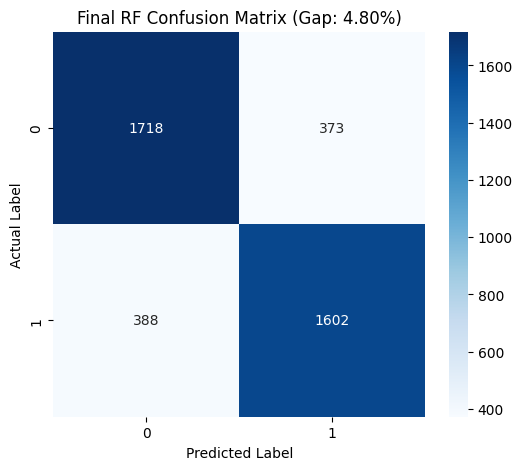

In [87]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d', cmap='Blues')
plt.title('Final RF Confusion Matrix (Gap: 4.80%)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Eski confusion matrixten biraz daha az başarısız ancak ona çok yakın olan değerlerimiz var.

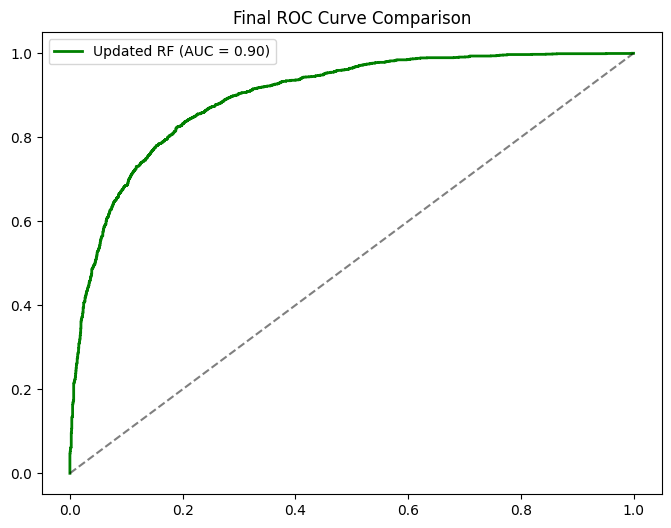

In [89]:
plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, y_prob_new)
plt.plot(fpr, tpr, label=f'Updated RF (AUC = {auc(fpr, tpr):.2f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Final ROC Curve Comparison')
plt.legend()
plt.show()



ROC eğrimiz hala 0.90, bu iyi haber

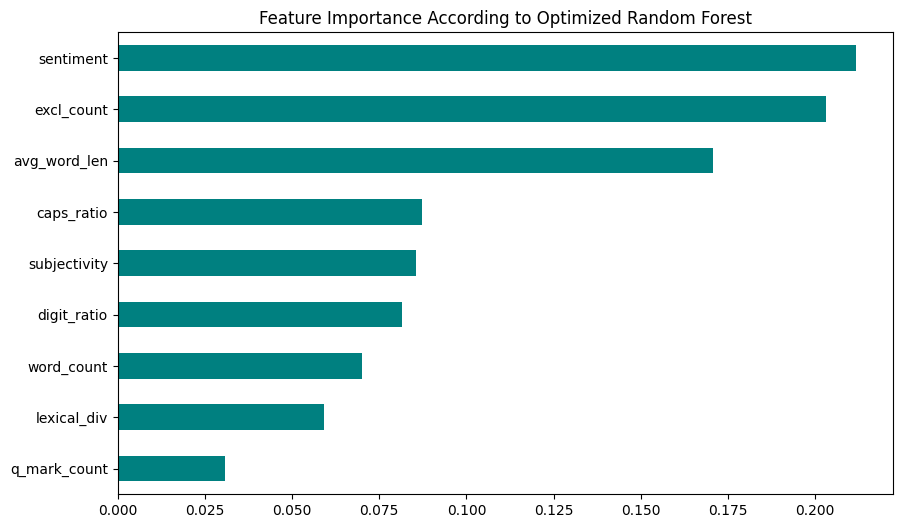

In [91]:
plt.figure(figsize=(10,6))
feat_importances = pd.Series(updated_rf.feature_importances_, index=new_feature_names)
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance According to Optimized Random Forest')
plt.show()

Düzenleme yaptıktan sonra ortalama kelime uzunluğu 2 den 3 e düştü.

Diğer modellerin overfitting durumlarını kontrol edelim ve tekrar tabloya dökelim

In [92]:
final_comparison = {
    "Logistic Regression": best_lr,
    "KNN (K=12)": KNeighborsClassifier(n_neighbors=12),
    "Random Forest (Fixed)": updated_rf,
    "Support Vector Machine": best_svm,
    "Neural Network (ANN)": best_mlp,
    "Gradient Boosting": best_gb,
    "AdaBoost": best_ada,
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Naive Bayes": best_nb
}

health_check = []

for name, model in final_comparison.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = (train_acc - test_acc) * 100

    health_check.append({
        "Model": name,
        "Train Acc": f"%{train_acc*100:.2f}",
        "Test Acc": f"%{test_acc*100:.2f}",
        "Gap": f"%{gap:.2f}",
        "Status": "Healthy" if gap < 10 else "Overfitting!"
    })

# Tabloyu görüntüle
health_df = pd.DataFrame(health_check)
print(health_df)

                    Model Train Acc Test Acc    Gap   Status
0     Logistic Regression    %77.95   %77.43  %0.52  Healthy
1              KNN (K=12)    %81.03   %77.51  %3.53  Healthy
2   Random Forest (Fixed)    %86.15   %81.35  %4.80  Healthy
3  Support Vector Machine    %78.82   %77.97  %0.85  Healthy
4    Neural Network (ANN)    %83.47   %82.16  %1.31  Healthy
5       Gradient Boosting    %83.18   %81.50  %1.68  Healthy
6                AdaBoost    %79.03   %78.04  %0.99  Healthy
7           Decision Tree    %78.32   %76.72  %1.60  Healthy
8             Naive Bayes    %62.07   %61.33  %0.74  Healthy


Şuanki modellerimize overfitting ihtimali düşük görünüyor. Ve en yüksek test accuracy değeri ANN'de.

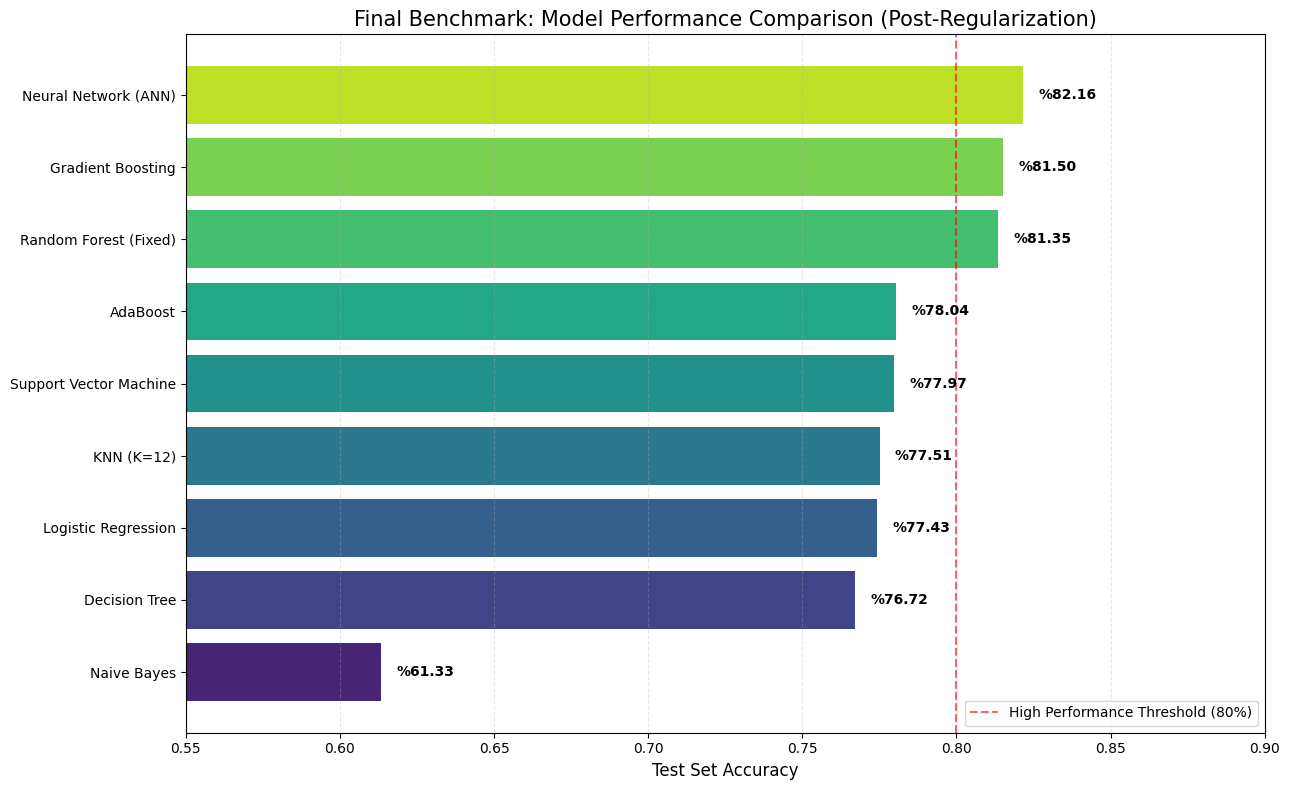

In [93]:
# Test Accuracy değerlerini sayısal olarak alalım
test_accuracies = [model.score(X_test, y_test) for model in final_comparison.values()]
model_names = list(final_comparison.keys())

plt.figure(figsize=(13, 8))
sorted_idx = np.argsort(test_accuracies)
sorted_names = [model_names[i] for i in sorted_idx]
sorted_accs = [test_accuracies[i] for i in sorted_idx]

colors = sns.color_palette("viridis", len(sorted_accs))
bars = plt.barh(sorted_names, sorted_accs, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'%{width*100:.2f}', va='center', fontweight='bold')

plt.axvline(x=0.80, color='red', linestyle='--', alpha=0.6, label='High Performance Threshold (80%)')
plt.xlim(0.55, 0.90)
plt.title('Final Benchmark: Model Performance Comparison (Post-Regularization)', fontsize=15)
plt.xlabel('Test Set Accuracy', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Bu sonuçlara göre, sıralama ANN > Gradient > Random forest olmuş. Eski grafiğe çok benziyor ve aralarındaki fark çok çok az. Ancak en başarılı olan ANN şuan.Ve ANN değeri eskisiyle aynı o yüzden confusion matrix aynı çıkmalı.

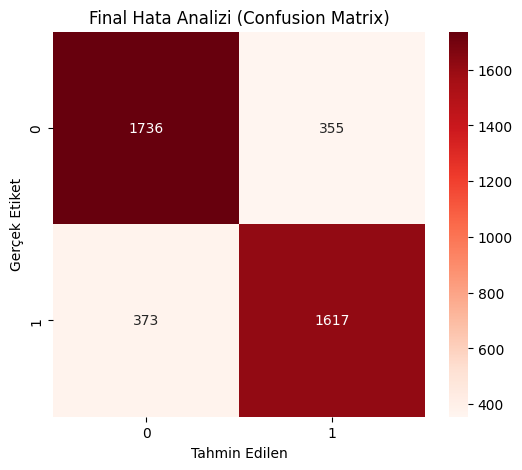


--- FINAL SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      2091
           1       0.82      0.81      0.82      1990

    accuracy                           0.82      4081
   macro avg       0.82      0.82      0.82      4081
weighted avg       0.82      0.82      0.82      4081



In [99]:
# Modeli test setinde çalıştıralım
best_mlp.fit(X_train, y_train)
y_pred = best_mlp.predict(X_test)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Final Hata Analizi (Confusion Matrix)')
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen')
plt.show()

print("\n--- FINAL SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))

Tahmin ettiğimiz gibi önceki MLP confusion matrix ile aynı değerler çıktı.

Daha iyi görebilmek için hepsinin ROC eğrisini de çizdirelim.

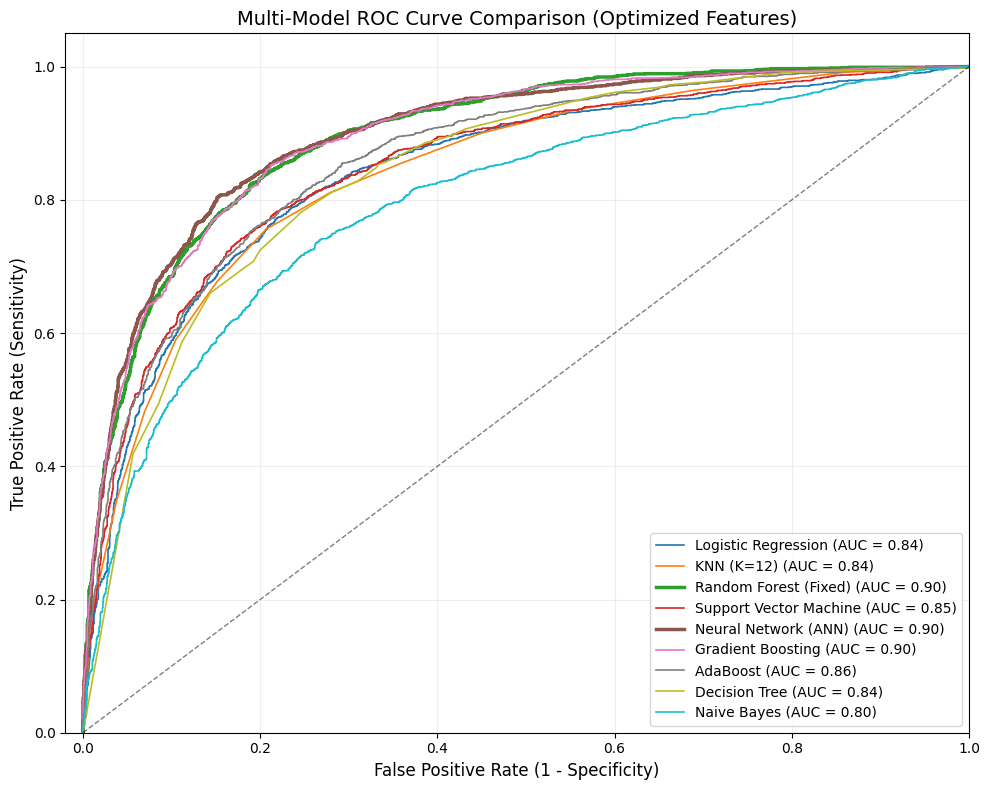

In [95]:
plt.figure(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(final_comparison)))

for (name, model), color in zip(final_comparison.items(), colors):
    if hasattr(model, "predict_proba"):  # naive bayes ve svm için olasılık
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    lw = 2.5 if name in ["Neural Network (ANN)", "Random Forest (Fixed)"] else 1.2
    plt.plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Multi-Model ROC Curve Comparison (Optimized Features)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

ANN,fixed random forest ve Gradient Boosting AUC değeri 0.90 geldi.Grafiğe göre altında kalan alan en fazla olan ROC eğrisine sahip model yine Neural Network modeli.

Gelişmiş Özellik Mühendisliği: Veri setine 3 yeni özellik daha eklenir: avg_word_len (ortalama kelime uzunluğu), q_mark_count (soru işareti sayısı) ve digit_ratio (rakam oranı).

Hiperparametre Optimizasyonu: GridSearchCV kullanılarak modellerin en iyi parametreleri bulunur.

Aşırı Öğrenme (Overfit) Kontrolü: "Pruning" (budama) teknikleriyle modellerin eğitim ve test seti arasındaki farkı (%16'dan %4.80'e) düşürülür.

Geniş Model Karşılaştırması: ANN (Yapay Sinir Ağları), Gradient Boosting, AdaBoost, SVM ve Naive Bayes gibi 9 farklı mimari birbiriyle kıyaslanır.

Nihai Karar: Projenin en iyi sonuç veren modelleri olan ANN ve optimize edilmiş Random Forest'ın final metrikleri üretilir.